In [64]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [65]:
#Generate Synthetic data
def generate_data(num_samples):
    np.random.seed(42)
    X=np.random.rand(num_samples,1)+10 #Features
    y=3*X+7+np.random.randn(num_samples,1)#Target with some noise
    return X,y

In [66]:
#Mean Squared Error(Loss Function)
def compute_loss(y_true,y_pred):
    return np.mean((y_true-y_pred)**2)

In [80]:
#Batch Gradient Descent(Vanilla GD)
def batch_gradient_descent(X,y,epochs,lr=0.0001):
    m,n=X.shape
    X=np.c_[np.ones((m,1)),X] #Add bias term
    np.random.rand(42)
    theta=np.random.randn(n+1,1)
    losses=[]

    for epoch in range(epochs):
        predictions=X.dot(theta)
        errors=predictions-y
        gradients=2/m*X.T.dot(errors)
        theta-=lr*gradients
        loss=compute_loss(y,predictions)
        losses.append(loss)
    return theta,losses

In [81]:
#Stochastic Gradient Descent

def stochastic_gradient_descent(X,y,epochs,lr=0.0001):
    m,n=X.shape
    X=np.c_[np.ones((m,1)),X] #Add bias term
    np.random.rand(42)
    theta=np.random.randn(n+1,1)
    losses=[]


    for epoch in range(epochs):

        random_index=np.random.randint(m)
        xi=X[random_index:random_index+1]
        yi=y[random_index:random_index+1]
        predictions=xi.dot(theta)
        errors=predictions-yi
        gradients=2*xi.T.dot(errors)
        theta-=lr*gradients
        loss= compute_loss(yi,predictions)
        losses.append(loss)

    return theta,losses

In [82]:
 #Comparison on small and Large Datasets
small_dataset_size=1000
large_dataset_size=10000000

X_small,y_small=generate_data(small_dataset_size)
X_large,y_large=generate_data(large_dataset_size)

Run Batch Gradient Descent

In [88]:
#for small dataset

start_time=time.time()
theta_bgd_small, losses_bgd_small=batch_gradient_descent(X_small, y_small,epochs=70)
time_bgd_small=time.time()- start_time

#for large dataset
start_time=time.time()
theta_bgd_large,losses_bgd_large=batch_gradient_descent(X_large,y_large,epochs=50)
time_bgd_large=time.time()- start_time

Run stochastic gradient descent

In [98]:
#for small datset

start_time=time.time()
theta_sgd_small, losses_sgd_small=stochastic_gradient_descent(X_small,y_small,epochs=50)
time_sgd_small=time.time()-start_time

#for large dataset

start_time=time.time()
theta_sgd_large, losses_sgd_large=stochastic_gradient_descent(X_large,y_large,epochs=70)
time_sgd_large=time.time()-start_time

Print Results

In [99]:
print("Batch Gradient Descent(Small Dataset): Time={:.4f}s,Final loss={:.4f}".format(time_bgd_small,losses_bgd_small[-1]))
print("Batch Gradient Descent(Large Dataset): Time={:.4f}s,Final loss={:.4f}".format(time_bgd_large,losses_bgd_large[-1]))
print("Stochastic Gradient Descent(Small Dataset): Time={:.4f}s,Final loss={:.4f}".format(time_sgd_small,losses_sgd_small[-1]))
print("Stochastic Gradient Descent(Large Dataset): Time={:.4f}s,Final loss={:.4f}".format(time_sgd_large,losses_sgd_large[-1]))

Batch Gradient Descent(Small Dataset): Time=0.0048s,Final loss=120.4662
Batch Gradient Descent(Large Dataset): Time=12.6528s,Final loss=63.5229
Stochastic Gradient Descent(Small Dataset): Time=0.0075s,Final loss=151.0748
Stochastic Gradient Descent(Large Dataset): Time=0.1207s,Final loss=9.1179


Plot losses

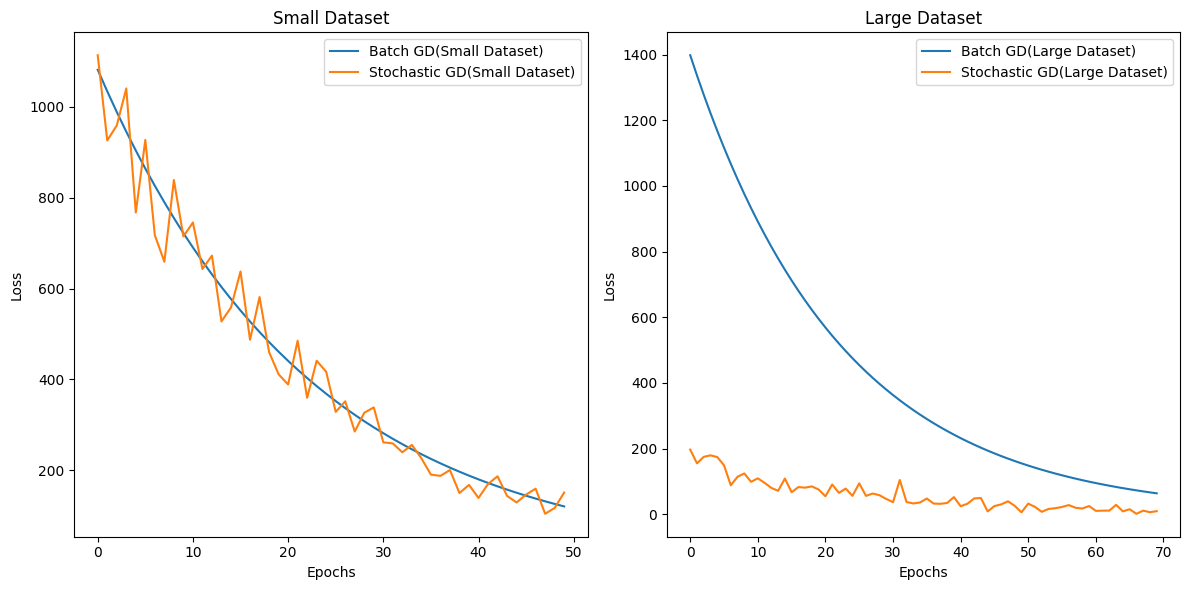

In [100]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(losses_bgd_small,label="Batch GD(Small Dataset)")
plt.plot(losses_sgd_small,label="Stochastic GD(Small Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Small Dataset")

plt.subplot(1,2,2)
plt.plot(losses_bgd_large,label="Batch GD(Large Dataset)")
plt.plot(losses_sgd_large,label="Stochastic GD(Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Large Dataset")

plt.tight_layout()
plt.show()